#📘 Week 1 Assignment — ML Foundations

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


##Part 1 — Python Fundamentals
1.1 Data Types & Control Flow


In [2]:
def classify_number(n):
    if n<0:
      return('negative')
    elif n==0:
       return('zero')
    elif 0<n<=10:
       return('small positive')
    else:
       return('large positive')


# Tests
assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


###1.2 Data Structures

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. word_count dict
word_count = {}

for word in words:
  if word in word_count:
    word_count[word]= word_count[word]+1
  else:
    word_count[word]=1

# 2. unique_words set
unique_words=set(words)


# 3. long_words list comprehension
long_words =[]

for i in words:
  if len(i)>5:
    long_words.append(i)


# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")


1.2 passed ✓


### 1.3 Exceptions

In [4]:
def safe_divide(a, b):
    if not (isinstance(a, (int, float)) and isinstance(b, (int, float))):
        raise TypeError("Inputs must be numeric")

    try:
        return a / b

    except ZeroDivisionError:
        return None


# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


###1.4 Functions & Lambdas

In [5]:

def apply_twice(f, x):
    return f(f(x))
    pass
triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


## Part 2 — NumPy
### 2.1 Array Creation & Shapes

In [6]:
import numpy as np

# 1D array
arr1d = np.arange(0, 12)

# 2D array of shape (3,4)
arr2d = arr1d.reshape(3, 4)

# 3D array of shape (2,2,3)
arr3d = arr1d.reshape(2, 2, 3)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

In [7]:
row2 = arr2d[1]

col3 = arr2d[:, 2]

sub = arr2d[1:, 2:]

gt7 = arr2d[arr2d > 7]

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

In [8]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# Element-wise multiplication
C = A * B

# Matrix multiplication
D = A @ B

# Dot product
dp = np.dot([1,2,3], [4,5,6])

# Scalar multiplication
E = A * 3

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓



## Part 3 — Pandas

In [9]:
# Load dataset
import pandas as pd
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

In [10]:
salary_series = df["salary"]

name_dept_df = df[["name", "department"]]



assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

In [11]:

iloc_result = df.iloc[2:5, 0:3]

loc_result = df.loc[[5, 6], ["name", "salary"]]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)


3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

In [12]:
senior_eng = df[(df["department"] == "Engineering") & (df["salary"] > 90000)]

dept_stats = df.groupby("department")[["salary", "performance"]].mean()

dept_stats = dept_stats.sort_values(by="salary", ascending=False)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,salary,performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

In [13]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()

median=df['salary'].median()
df_filled['salary']=df['salary'].fillna(median)
mean=round(df['age'].mean())
df_filled['age']=df['age'].fillna(mean)
df_filled=df_filled.dropna(subset=['performance'])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓



## Part 4 — Linear Algebra
### 4.1 Vectors & Matrices as Data

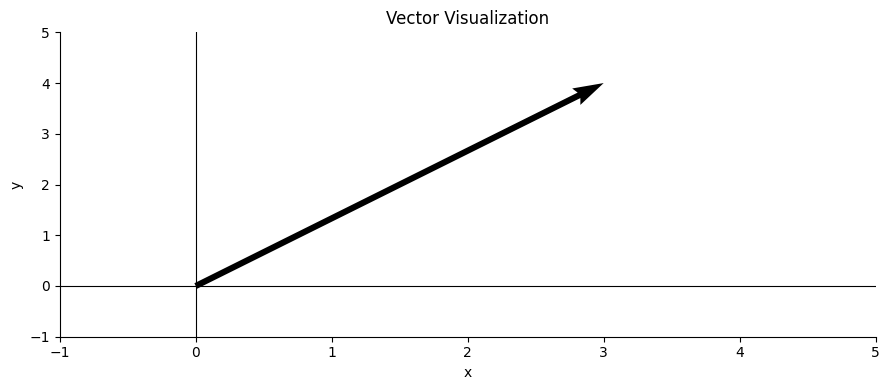

4.1 passed ✓  |v| = 5.0


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Vector
v = np.array([3, 4])

# L2 Norm
norm_v= np.linalg.norm(v)

# 3x3 Matrix
M = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]])

# Plot
fig, ax = plt.subplots()
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1)

ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

In [15]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ   = P + Q
scalar3P = 3 * P
PQ       = P@Q
QP       = Q@P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Eigenpair 1
A @ v = [3.53553391 3.53553391]
λ * v = [3.53553391 3.53553391]

Eigenpair 2
A @ v = [-0.89442719  1.78885438]
λ * v = [-0.89442719  1.78885438]


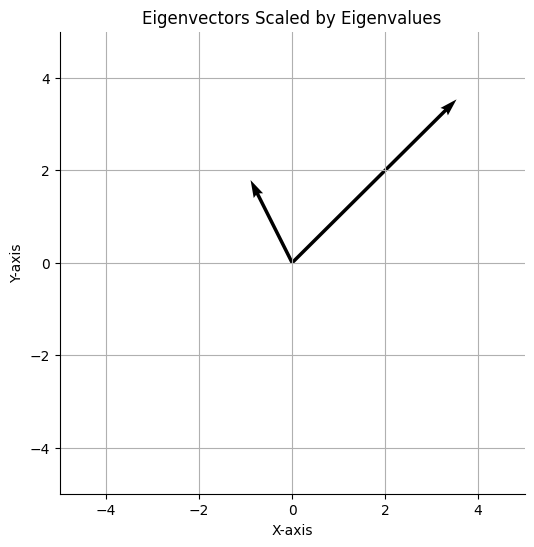

4.3 passed ✓


In [16]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

# Verify Av = λv for each eigenpair
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]

    print(f"\nEigenpair {i+1}")
    print("A @ v =", A @ v)
    print("λ * v =", lam * v)

# Plot
plt.figure(figsize=(6,6))

for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]

    plt.quiver(0, 0,lam * v[0],lam * v[1],angles='xy',scale_units='xy',scale=1)

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Eigenvectors Scaled by Eigenvalues")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid(True)
plt.show()


print("4.3 passed ✓")

**Your Geometric Explanation (4.3):**

Eigenvectors are special vectors that keep the same direction after a matrix transformation. Eigenvalues tell how much those vectors are stretched or compressed. A larger eigenvalue means more stretching, while a smaller eigenvalue means the vector is squished.


### 4.4 SVD & Dimensionality Reduction

In [17]:
np.random.seed(42)
X = np.random.randn(4, 3)


U, S, Vt = np.linalg.svd(X, full_matrices=False)


X_reconstructed = U @ np.diag(S) @ Vt  #reconstruct from U, S, Vt

X_approx = S[0] * np.outer(U[:,0], Vt[0,:])  #rank-1 approximation

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 8.01e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

SVD breaks a matrix into three parts: U, S, and Vt. The matrix S contains the singular values, which show the importance of each component, while Vt contains the principal directions of the data. In PCA, these directions represent the axes with the maximum variance, so Vt contains the principal components used for dimensionality reduction.



## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


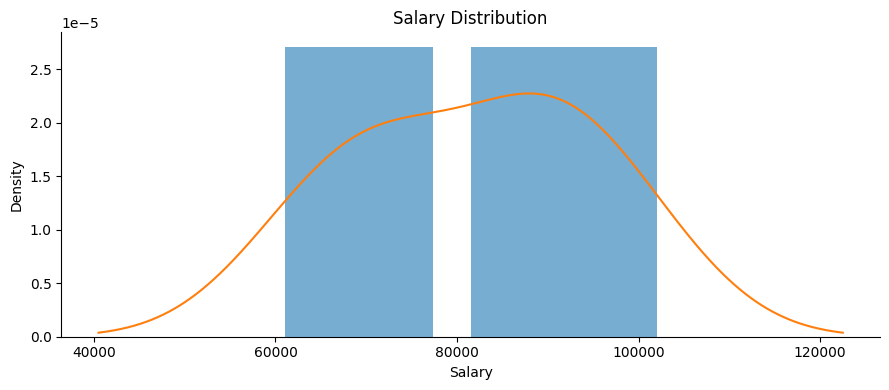

In [18]:
salary = df_filled['salary']


mean_s=salary.mean()

median_s=salary.median()

std_s=salary.std()

min_s=salary.min()

max_s=salary.max()

Q1 = np.percentile(salary, 25)
Q3 = np.percentile(salary, 75)
iqr_s = Q3 - Q1

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()
df_filled["salary"].plot(kind="hist",bins=10,density=True,alpha=0.6,ax=ax)

df_filled["salary"].plot(kind="kde",ax=ax)

ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
plt.tight_layout(); plt.show()

**Definitions (5.1):**

**Population:** The complete set of all individuals or observations of interest in a study.

**Sample:** A subset of the population selected for analysis.

**Descriptive statistic:** A numerical measure used to summarize and describe data, such as mean or median.

**Inferential statistic:** A statistical method used to draw conclusions about a population based on sample data.

### 5.2 Hypothesis Testing

In [19]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

# One-sample t-test

t_stat, p_value = stats.ttest_1samp(eng_salaries,overall_mean)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

# Pearson correlation

r, r_pval = stats.pearsonr(df_filled['salary'],df_filled['years_exp'])

print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

**H₀:** The mean salary of Engineering employees is equal to the overall company mean salary.

**H₁:** The mean salary of Engineering employees is higher than the overall company mean salary.

**Conclusion:** If the p-value is less than 0.05, we reject H₀ and conclude that Engineering salaries are significantly higher than the company average. Otherwise, we fail to reject H₀ and conclude that there is not enough evidence to say Engineering salaries are significantly higher.

### 5.3 Error Metrics

In [20]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2


mae = np.mean(np.abs(y_true - y_pred))

mse = np.mean((y_true - y_pred) ** 2)

rmse = np.sqrt(mse)

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

r2 = 1 - (ss_res / ss_tot)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

In [21]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

# KS test — compare each against N(0,1)

ks_s1 = stats.kstest(s1, 'norm')

ks_s2 = stats.kstest(s2, 'norm')
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

# ADF test on non-stationary series
t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)


adf_result = adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

# Difference once and re-run

ts_diff = np.diff(ts)

adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


5.5 Model Monitoring Concepts

PSI: 1.4848
Shift severity: Major


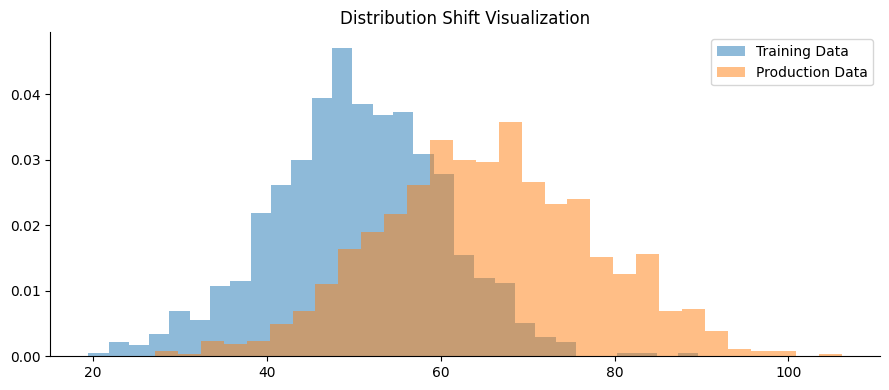

In [22]:
def compute_psi(expected, actual, bins=10):
    """
    PSI = sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))
    Add epsilon=1e-10 to avoid log(0).
    """
    epsilon = 1e-10
    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    psi = np.sum(
        (actual_pct - expected_pct)
        * np.log(
            (actual_pct + epsilon)
            /
            (expected_pct + epsilon)))

    return psi


np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)    # training distribution
drift_dist = np.random.normal(65, 12, 1000)    # shifted production distribution

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
ax.hist(train_dist,bins=30,alpha=0.5,density=True,label='Training Data')

ax.hist(drift_dist,bins=30,alpha=0.5,density=True,label='Production Data')
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

**Concept Drift:** Concept drift happens when the relationship between the input data and the target variable changes over time, causing the model's predictions to become less accurate.

**Covariate Drift:** Covariate drift occurs when the distribution of input features changes, but the relationship between the inputs and outputs remains the same.

**PSI < 0.1: **The distribution is stable and there is no significant shift.

**PSI 0.1–0.2:** There is a minor shift in the distribution and it should be monitored.

**PSI > 0.2:** There is a major shift in the distribution and the model may need attention or retraining.

**Retraining trigger example:** If the PSI value becomes greater than 0.2 or the model's prediction accuracy drops significantly, the model should be retrained.



## Part 6 — Probability Theory
### 6.1 Core Concepts

In [23]:
total = 10
red, blue, green = 4, 3, 3


p_red=red/total

p_blue = blue / total

p_green = green / total

# Joint: P(red first AND blue second)

p_red_then_blue = (4/10) * (3/9)

# Conditional: P(blue second | red first)

p_blue_given_red = 3/9

# Independence check: are P(B|A) == P(B) ?

independent = (p_blue_given_red == p_blue)

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

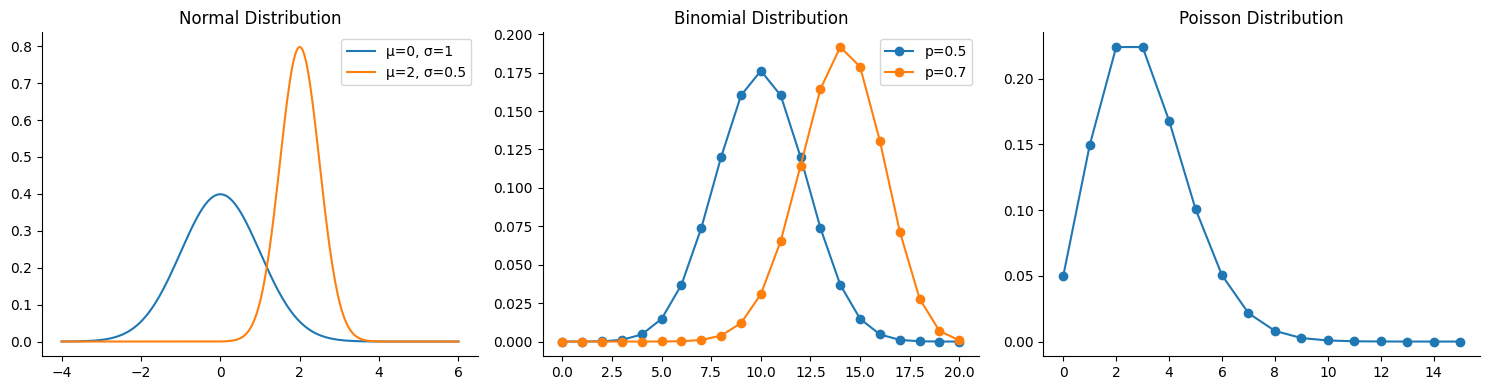

In [24]:
from scipy.stats import norm, binom, poisson
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────────────────────────────
x = np.linspace(-4, 6, 300)
axes[0].plot(x, norm.pdf(x, 0, 1), label='μ=0, σ=1')
axes[0].plot(x, norm.pdf(x, 2, 0.5), label='μ=2, σ=0.5')

axes[0].legend()
# ML use case:Normal Distribution is used in many ML models assume features such as height,weight, exam scores, or measurement errors follow a normal distribution.
axes[0].set_title('Normal Distribution')

# ── Binomial ────────────────────────────────────────────────────────────────
k = np.arange(0, 21)
axes[1].plot(k, binom.pmf(k, 20, 0.5),
             marker='o', label='p=0.5')

axes[1].plot(k, binom.pmf(k, 20, 0.7),
             marker='o', label='p=0.7')

axes[1].legend()
# ML use case:  Binomial Distribution is used in binary classification problems such as spam detection (spam/not spam) or fraud detection (fraud/not fraud).
axes[1].set_title('Binomial Distribution')

# ── Poisson ─────────────────────────────────────────────────────────────────
k2 = np.arange(0, 16)

axes[2].plot(
    k2,
    poisson.pmf(k2, 3),
    marker='o'
)
# ML use case: Poisson Distribution is used to model count-based events such as the number of website clicks, customer arrivals, or support tickets per hour.
axes[2].set_title('Poisson Distribution')

plt.tight_layout(); plt.show()

### 6.3 Bayes' Theorem

In [25]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

# P(free) — law of total probability

p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
# Bayes

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    prior_ham = 1 - prior_spam

    p_word = (
        p_word_given_spam * prior_spam
        + p_word_given_ham * prior_ham
    )

    posterior = (
        p_word_given_spam * prior_spam
    ) / p_word

    return posterior


pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this Example |
|------|---------|----------------|
| Prior | P(Spam) | Probability that an email is spam before seeing any words = 0.30 |
| Likelihood | P("free" \| Spam) | Probability of seeing the word "free" given that the email is spam = 0.80 |
| Evidence | P("free") | Overall probability of seeing the word "free" in any email = 0.275 |
| Posterior | P(Spam \| "free") | Probability that an email is spam after seeing the word "free" = 0.8727 |

### 6.4 Central Limit Theorem

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 0.9971, std: 0.1828
CLT predicted std: 0.1827


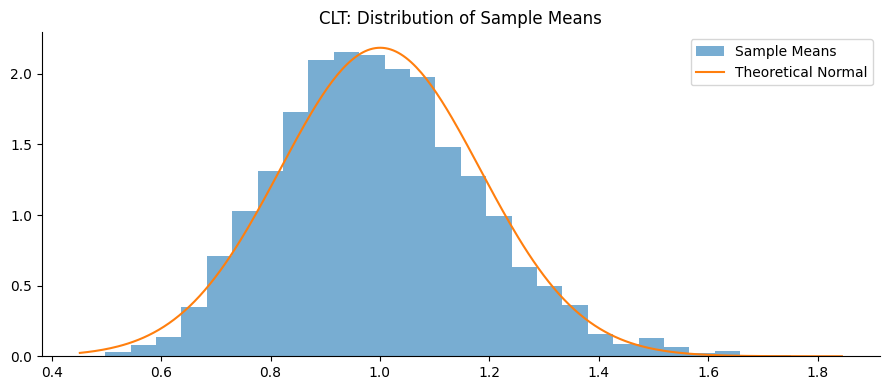

KS test p-value: 0.0000 → Approximately normal? False


In [26]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30

sample_means = np.array([np.mean(np.random.choice(population,sample_size,replace=True))
    for _ in range(n_samples)])
pop_mean = population.mean()
pop_std  = population.std()

clt_std = pop_std / np.sqrt(sample_size)


print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()
ax.hist(sample_means,bins=30,density=True,alpha=0.6,label='Sample Means')

x = np.linspace(sample_means.min(),sample_means.max(),300)

ax.plot(x,stats.norm.pdf(x, pop_mean, clt_std),label='Theoretical Normal')

ax.legend()
ax.set_title('CLT: Distribution of Sample Means')
plt.tight_layout(); plt.show()

# KS test
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

The Central Limit Theorem is important because it helps us analyze data more easily, even when the original data is not normally distributed. As we take larger samples, the sample means tend to follow a normal distribution. This allows us to use many statistical methods, such as confidence intervals and hypothesis tests, which assume normality.
